# Broadcasting and Functions

*If you haven't read [Getting Started](../tutorials/getting_started.ipynb)
or [Distribution basics](01_distributions.ipynb), read those first.*

Every op in ProbPipe — `sample`, `log_prob`, `mean`, `condition_on`,
... — is a `@function` under the hood. This notebook
explains the mechanism: automatic uncertainty propagation when a
`Distribution` is passed where a concrete value is expected,
component-grouping for correlation preservation via `select()`
splatting, seeded reproducibility, orchestration hints, and the
`jax` vs `sequential` dispatch auto-detection.

Contents:

1. Basic broadcasting — `Distribution` in, `Distribution` out.
2. Multiple and mixed arguments.
3. `EmpiricalDistribution` enumeration and budget-aware cutoff.
4. Dispatch: `jax` vs `sequential`, `auto` detection.
5. Multivariate broadcasting.
6. Workflow RNG and reproducibility.
7. Non-numeric results.
8. Provenance tracking.
9. External distributions via the converter registry.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import Normal, MultivariateNormal, EmpiricalDistribution, BroadcastDistribution, provenance_ancestors, workflow_run
from probpipe.core.node import Function, function
from probpipe import expectation, log_prob, mean, prob, sample

## Basic Broadcasting

When a function's type hint expects `jnp.ndarray` but the caller passes a `Normal` (or any `Distribution`), the `Function` detects the mismatch and **broadcasts** automatically: it draws `n_broadcast_samples` from the distribution, calls the function once per sample, and returns the output distribution directly. `n_broadcast_samples` can be set with `@function(...)` or overridden for one call with `workflow.with_options(...)(...)`.

> **Note:** `n_broadcast_samples`, `seed`, and `include_inputs` may be ordinary function parameters. Use `workflow.with_options(...)(...)` for one-call broadcasting controls; use `workflow_run(seed=...)` to reproduce workflow-owned randomness.

In [2]:
@function
def double_it(x: jnp.ndarray) -> jnp.ndarray:
    return x * 2

g = Normal(loc=3.0, scale=1.0, name="auto_d1")
# override the default sample count for this one call
result = double_it.with_options(n_broadcast_samples=1_000)(g)

print(f"Input: Normal(loc=3, scale=1)")
print(f"Output type: {type(result).__name__} with {result.num_atoms} samples")
print(f"Output mean ≈ {float(jnp.mean(result.samples)):.3f} (expected ≈ 6.0)")

Input: Normal(loc=3, scale=1)
Output type: _RecordMarginal with 1000 samples
Output mean ≈ 5.982 (expected ≈ 6.0)


The plots below show the input distribution alongside the pushforward, both as histograms and as analytic densities (computed directly, not through `prob`, to avoid a tracer-escape issue inside `jax.vmap` — see the inline note in the code):

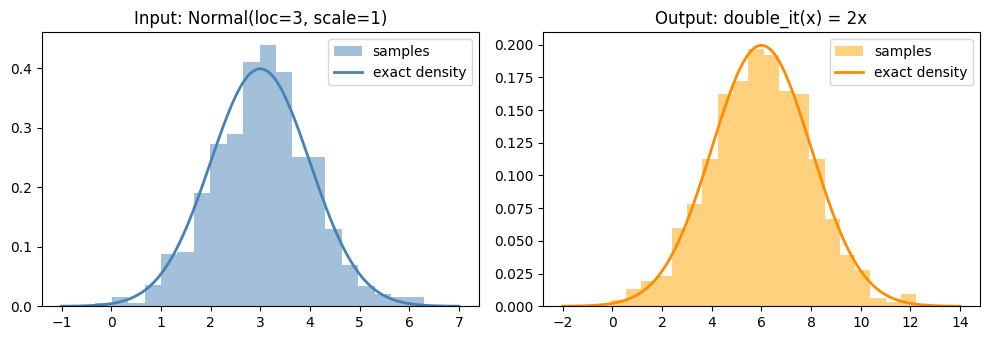

In [3]:
# Plot input vs output distributions with density overlays
input_samples = sample(g, sample_shape=(1_000,))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Input histogram + exact density
xs_in = np.linspace(-1, 7, 200)
# NOTE: prob(g, v) inside jax.vmap raises UnexpectedTracerError —
# Function state escapes the trace scope (see issue #163).
# Bypass the WF layer and call the protocol method directly.
input_density = jax.vmap(lambda v: jnp.exp(g._log_prob(v)))(jnp.array(xs_in))
ax1.hist(np.array(input_samples), bins=20, density=True, alpha=0.5, color="steelblue", label="samples")
ax1.plot(xs_in, np.array(input_density), color="steelblue", linewidth=2, label="exact density")
ax1.set_title("Input: Normal(loc=3, scale=1)")
ax1.legend()

# Output histogram + exact density (Normal(6, 2, name="auto_d1") since doubling scales loc and scale)
xs_out = np.linspace(-2, 14, 200)
output_dist = Normal(loc=6.0, scale=2.0, name="auto_d2")
output_density = jax.vmap(lambda v: jnp.exp(output_dist._log_prob(v)))(jnp.array(xs_out))
ax2.hist(np.array(result.samples), bins=20, density=True, alpha=0.5, color="orange", label="samples")
ax2.plot(xs_out, np.array(output_density), color="darkorange", linewidth=2, label="exact density")
ax2.set_title("Output: double_it(x) = 2x")
ax2.legend()

plt.tight_layout()
plt.show()

The output marginal supports `expectation()`, which computes an exact weighted sum. To disable error tracking on parametric distributions, pass `return_dist=False`.

In [4]:
# Exact expectation on the broadcast result's output marginal
ex_result = expectation(result, lambda x: x)
print(f"E[2X] from broadcast: {float(ex_result):.4f} (exact over samples)")

# For parametric distributions, use return_dist=False for a plain scalar
input_dist = Normal(loc=3.0, scale=1.0, name="auto_d3")
ex_plain = expectation(input_dist, lambda x: 2*x,
return_dist=False)
print(f"E[2X] from Normal:    {float(ex_plain):.4f} (MC point estimate)")

E[2X] from broadcast: 5.9818 (exact over samples)
E[2X] from Normal:    5.9786 (MC point estimate)


## Multiple Distribution Arguments

When multiple arguments receive distributions, the i-th call uses the i-th sample from every distribution argument. Arguments that come from *different* distributions are sampled independently, so the calls draw from the product of their laws. Arguments that refer to the *same* distribution — the same object passed twice, or two field views of one joint law — instead share a single draw per call, so `f(d, d)` evaluates `f` on one realization rather than two.

In [5]:
@function(n_broadcast_samples=500, dispatch="sequential")
def weighted_sum(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    return 0.7 * a + 0.3 * b

result = weighted_sum(Normal(loc=10.0, scale=1.0, name="auto_d4"), Normal(loc=0.0, scale=2.0, name="auto_d5"))
print(f"Number of samples: {result.num_atoms}")
print(f"Output dimension: {result.dim}")
print(f"Mean ≈ {float(jnp.mean(result.samples)):.3f} (expected ≈ 7.0)")
print(f"Std  ≈ {float(jnp.std(result.samples)):.3f} (expected ≈ {(0.7**2 + (0.3*2)**2)**0.5:.3f})")

Number of samples: 500
Output dimension: 1
Mean ≈ 7.037 (expected ≈ 7.0)
Std  ≈ 0.934 (expected ≈ 0.922)


Note how the default value of `n_broadcast_samples` is set to 500 with `@function(...)`. Hence, `result` is an `EmpiricalDistribution` of 500 samples.

## Mixed Distribution and Concrete Arguments

Only distribution arguments are broadcast; concrete values (floats, arrays) pass through unchanged to every function call.

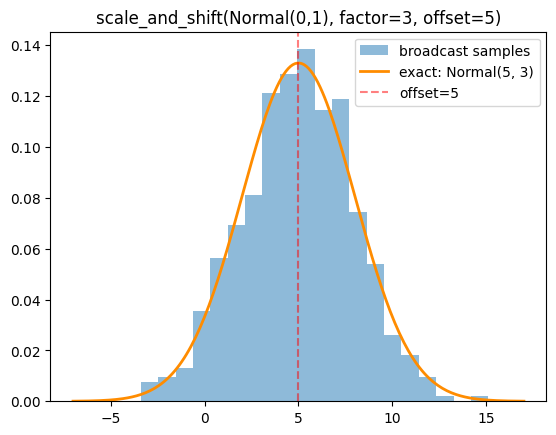

In [6]:
@function
def scale_and_shift(x: jnp.ndarray, factor: float, offset: float) -> jnp.ndarray:
    return x * factor + offset

result = scale_and_shift.with_options(n_broadcast_samples=1_000)(Normal(loc=0.0, scale=1.0, name="auto_d6"), 3.0, 5.0)
# Exact output distribution: Normal(loc=0*3+5=5, scale=1*3=3, name="auto_d2")
exact = Normal(loc=5.0, scale=3.0, name="auto_d7")
xs = np.linspace(-7, 17, 200)
exact_density = jax.vmap(lambda v: prob(exact, v))(jnp.array(xs))

plt.hist(np.array(result.samples), bins=20, density=True, alpha=0.5, label="broadcast samples")
plt.plot(xs, np.array(exact_density), color="darkorange", linewidth=2, label="exact: Normal(5, 3)")
plt.axvline(5.0, color="red", linestyle="--", alpha=0.5, label="offset=5")
plt.title("scale_and_shift(Normal(0,1), factor=3, offset=5)")
plt.legend()
plt.show()

## EmpiricalDistribution Enumeration

When an `EmpiricalDistribution` with support less than `n_broadcast_samples`, the workflow **enumerates** all samples instead of resampling. Weights are propagated exactly, so no information is lost.

In [7]:
def identity(x):
    return x

samples = jnp.array([[1.0], [2.0], [3.0]])
weights = jnp.array([0.2, 0.3, 0.5])
ed = EmpiricalDistribution("x", samples, weights)

w = Function(func=identity, n_broadcast_samples=100, dispatch="sequential")
result = w(ed)

print(f"Input: {ed.num_atoms} weighted samples")
print(f"Output: {result.num_atoms} samples (enumerated, not resampled to 100)")
print(f"Weights preserved: {np.allclose(result.weights, weights, atol=1e-5)}")

Input: 3 weighted samples
Output: 3 samples (enumerated, not resampled to 100)
Weights preserved: True


## Cartesian Product of Multiple Empirical Distributions

With two empirical distributions, the workflow forms the **cartesian product** of their samples and multiplies weights.

In [8]:
@function(dispatch="sequential")
def add_them(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    return a + b

ed1 = EmpiricalDistribution("a", jnp.array([[1.0], [2.0]]))
ed2 = EmpiricalDistribution("b", jnp.array([[10.0], [20.0], [30.0]]))

result = add_them(ed1, ed2)
print(f"Cartesian product: {ed1.num_atoms} × {ed2.num_atoms} = {result.num_atoms} evaluations")
print(f"Results: {np.asarray(result.samples).ravel()}")
print(f"Weights: {result.weights}")

Cartesian product: 2 × 3 = 6 evaluations
Results: [11. 21. 31. 12. 22. 32.]
Weights: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


## Budget-Aware Greedy Cutoff

When the cartesian product of all empirical distributions would exceed `n_broadcast_samples`, the workflow uses a **greedy strategy**: it enumerates the smallest empiricals first (sorted by size) and samples from the rest. This keeps total evaluations within budget while preserving as much exact enumeration as possible.

In [9]:
@function(n_broadcast_samples=50, dispatch="sequential")
def sum_three(a: jnp.ndarray, b: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
    return a + b + c

ed_small = EmpiricalDistribution("a", jnp.array([[1.0], [2.0]]))          # n=2
ed_medium = EmpiricalDistribution("b", jnp.arange(5).reshape(-1, 1).astype(jnp.float32))  # n=5
ed_large = EmpiricalDistribution("c", jnp.arange(20).reshape(-1, 1).astype(jnp.float32))  # n=20

result = sum_three(ed_small, ed_medium, ed_large)

print(f"Full product: {ed_small.num_atoms}\u00d7{ed_medium.num_atoms}\u00d7{ed_large.num_atoms} = {ed_small.num_atoms*ed_medium.num_atoms*ed_large.num_atoms}")
print(f"Budget: 50")
print(f"Enumerated: {ed_small.num_atoms}\u00d7{ed_medium.num_atoms} = 10 combos")
print(f"Sampled: {50//10} draws from ed_large per combo")
print(f"Total evaluations: {result.num_atoms}")

Full product: 2×5×20 = 200
Budget: 50
Enumerated: 2×5 = 10 combos
Sampled: 5 draws from ed_large per combo
Total evaluations: 50


## JAX vmap Backend

The `"jax"` dispatch strategy uses `jax.vmap` to vectorize the function over all samples at once, which is much faster for JAX-traceable functions. It draws all samples up front and applies the function in a single vectorized call.

In [10]:
import time

def transform(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.sin(x) ** 2 + jnp.cos(x)

g = Normal(loc=0.0, scale=1.0, name="auto_d9")

# Loop dispatch
w_seq = Function(func=transform, n_broadcast_samples=5000, dispatch="sequential")
t0 = time.perf_counter()
r_seq = w_seq(g)
t_seq = time.perf_counter() - t0

# JAX dispatch
w_jax = Function(func=transform, n_broadcast_samples=5000, dispatch="jax")
t0 = time.perf_counter()
r_jax = w_jax(g)
t_jax = time.perf_counter() - t0

print(f"Loop dispatch: {t_seq:.3f}s ({r_seq.num_atoms} samples)")
print(f"JAX  dispatch: {t_jax:.3f}s ({r_jax.num_atoms} samples)")
print(f"Speedup: {t_seq/t_jax:.1f}x")

Loop dispatch: 2.655s (5000 samples)
JAX  dispatch: 0.091s (5000 samples)
Speedup: 29.2x


## Auto Backend Detection

The default `"auto"` dispatch mode probes the function with `jax.make_jaxpr`. If the function is JAX-traceable, it selects `"jax"` (vmap); otherwise it falls back to `"sequential"`.

In [11]:
import scipy.special

# JAX-traceable -> auto selects "jax"
@function(n_broadcast_samples=50)
def jax_fn(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-x**2)

_ = jax_fn(Normal(loc=0.0, scale=1.0, name="auto_d10"))
print("jax_fn \u2192 dispatch: jax")

# Non-JAX -> auto selects "sequential"
@function(n_broadcast_samples=50)
def scipy_fn(x: jnp.ndarray) -> jnp.ndarray:
    return jnp.asarray(scipy.special.gamma(np.asarray(x)))

_ = scipy_fn(Normal(loc=2.0, scale=0.1, name="auto_d11"))
print("scipy_fn \u2192 dispatch: sequential")

jax_fn → dispatch: jax
scipy_fn → dispatch: sequential


## Multivariate Broadcasting

Broadcasting works with multivariate distributions too. Each sample is a vector, and the function receives one vector per call (or a batch of vectors with `"jax"` dispatch).

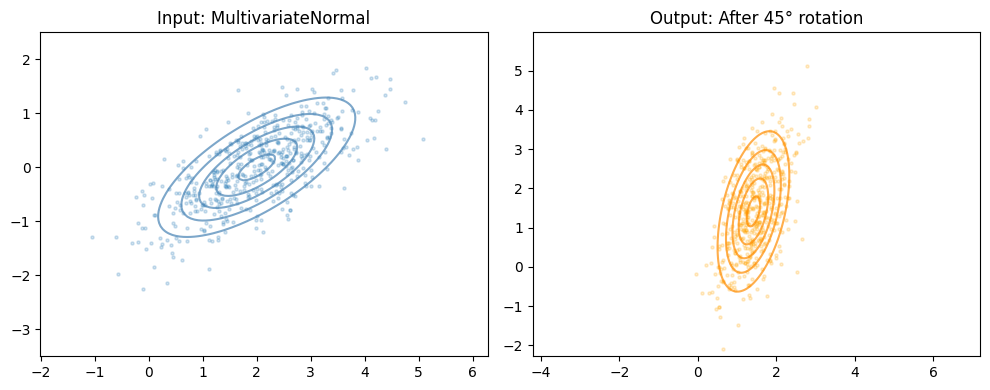

In [12]:
@function(n_broadcast_samples=500, dispatch="jax")
def project_2d(x: jnp.ndarray) -> jnp.ndarray:
    """Rotate a 2D vector by 45 degrees."""
    theta = jnp.pi / 4
    R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                    [jnp.sin(theta),  jnp.cos(theta)]])
    return R @ x

mvn = MultivariateNormal(loc=jnp.array([2.0, 0.0]), cov=jnp.array([[1.0, 0.5], [0.5, 0.5]]), name="auto_d12")
result = project_2d(mvn)
# Compute exact output distribution: R @ loc, R @ cov @ R^T
theta = jnp.pi / 4
R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                [jnp.sin(theta),  jnp.cos(theta)]])
out_loc = R @ jnp.array([2.0, 0.0])
in_cov = jnp.array([[1.0, 0.5], [0.5, 0.5]])
out_cov = R @ in_cov @ R.T
mvn_out = MultivariateNormal(loc=out_loc, cov=out_cov, name="auto_d13")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Helper to draw contours for a 2D MVN
def draw_contours(ax, mvn_dist, color, n_grid=100):
    loc = np.array(mvn_dist.loc)
    samples_for_range = np.asarray(sample(mvn_dist, sample_shape=(500,)))
    x_range = np.linspace(float(samples_for_range[:, 0].min()) - 0.5,
                          float(samples_for_range[:, 0].max()) + 0.5, n_grid)
    y_range = np.linspace(float(samples_for_range[:, 1].min()) - 0.5,
                          float(samples_for_range[:, 1].max()) + 0.5, n_grid)
    X, Y = np.meshgrid(x_range, y_range)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    Z = jax.vmap(lambda v: jnp.asarray(log_prob(mvn_dist, v)))(points).reshape(X.shape)
    ax.contour(X, Y, np.exp(np.array(Z)), levels=5, colors=color, alpha=0.7, linewidths=1.5)

input_samples = np.asarray(sample(mvn, sample_shape=(500,)))
ax1.scatter(input_samples[:, 0], input_samples[:, 1], alpha=0.2, s=5)
draw_contours(ax1, mvn, "steelblue")
ax1.set_title("Input: MultivariateNormal")
ax1.axis("equal")

out_samples = np.asarray(result.samples)
ax2.scatter(out_samples[:, 0], out_samples[:, 1], alpha=0.2, s=5, color="orange")
draw_contours(ax2, mvn_out, "darkorange")
ax2.set_title("Output: After 45° rotation")
ax2.axis("equal")
plt.tight_layout()
plt.show()

## Workflow RNG and Reproducibility

ProbPipe-owned randomness is controlled by `workflow_run`, not by `Function` construction or call options. Re-entering the same seed with the same call structure reproduces a result; consecutive stochastic calls inside one run receive different structural event identities. A bare stochastic call uses a fresh ephemeral root, so separate bare calls are intentionally independent.

An explicit sampling key remains caller-owned: it is passed through unchanged and does not advance the workflow stream. RNG ABI v1 has no call-local common-random-number replacement for the removed Function seed. To preserve a shared realization, express related quantities in one joint Function call, keep the resulting joint distribution, or materialize and reuse samples explicitly.

In [13]:
g = Normal(loc=0.0, scale=1.0, name="auto_d14")

w = Function(func=identity, n_broadcast_samples=10, dispatch="sequential")

with workflow_run(seed=0):
    r1 = w(g)
with workflow_run(seed=42):
    r2 = w(g)
s1 = np.asarray(r1.samples)
s2 = np.asarray(r2.samples)
print(f"Run seed 0:  {s1[:5].ravel()}")
print(f"Run seed 42: {s2[:5].ravel()}")
print(f"Same? {bool(jnp.allclose(s1, s2))}")

# Re-enter a run with the same seed to reproduce the call.
with workflow_run(seed=99):
    r_a = w(g)
with workflow_run(seed=99):
    r_b = w(g)
print(f"\nSame workflow seed: {bool(jnp.allclose(np.asarray(r_a.samples), np.asarray(r_b.samples)))}")

Run seed 0:  [ 1.4226011  -0.74395126  0.0734022  -1.7593237   0.49136558]
Run seed 42: [ 0.95903414 -0.7531428  -0.8142081  -0.5713623   1.5788715 ]
Same? False

Same workflow seed: True


## Non-Numeric Results

If the wrapped function returns non-numeric types (strings, dicts, etc.), broadcasting returns a `_ListMarginal` with no protocol support (no sampling or moments).

In [14]:
@function(n_broadcast_samples=5, dispatch="sequential")
def describe(x: jnp.ndarray) -> str:
    return f"value={float(x):.3f}, positive={bool(x > 0)}"

result = describe(Normal(loc=0.0, scale=1.0, name="auto_d15"))
print(f"Return type: {type(result).__name__}")
for r in result.items:
    print(f"  {r}")

Return type: _ListMarginal
  value=-0.646, positive=False
  value=-1.038, positive=False
  value=1.627, positive=True
  value=0.961, positive=True
  value=0.216, positive=True


## Provenance Tracking

Every distribution produced by broadcasting records which distributions were propagated, which dispatch strategy was used, and the function name. This makes it easy to trace how an output distribution was derived.

In [15]:
# Broadcast result records its provenance
a = Normal(loc=1.0, scale=0.5, name='param_a')
b = Normal(loc=2.0, scale=1.0, name='param_b')

@function(n_broadcast_samples=100, dispatch='sequential')
def multiply(x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    return x * y

result = multiply(a, b)

print(f'Source: {result.provenance}')
print(f'Operation:      {result.provenance.operation}')
print(f'Dispatch:       {result.provenance.metadata["dispatch"]}')
print(f'Function:       {result.provenance.metadata["func"]}')
print(f'Broadcast args: {result.provenance.metadata["broadcast_args"]}')
print(f'N samples:      {result.provenance.metadata["n_samples"]}')

# Trace ancestors — which distributions fed into this result?
ancestors = provenance_ancestors(result)
print(f'\nAncestors: {[anc.name for anc in ancestors]}')

# Serialization for logging/auditing
prov_dict = result.provenance.to_dict()
print(f'\nSerialized provenance:')
for k, v in prov_dict.items():
    print(f'  {k}: {v}')

Source: Provenance('broadcast', parents=[multiply, param_a, param_b])
Operation:      broadcast
Dispatch:       sequential
Function:       multiply
Broadcast args: ['x', 'y']
N samples:      100

Ancestors: ['multiply', 'param_a', 'param_b']

Serialized provenance:
  operation: broadcast
  parents: [{'type': 'Function', 'name': 'multiply', 'fingerprint': '17afc2bff4dfdb3f', 'fingerprint_is_weak': False}, {'type': 'Normal', 'name': 'param_a', 'fingerprint': 'd2c7b1c679f3703b', 'fingerprint_is_weak': False}, {'type': 'Normal', 'name': 'param_b', 'fingerprint': '7b3849464f7e4b68', 'fingerprint_is_weak': False}]
  inputs: {}
  metadata: {'dispatch': 'sequential', 'orchestrate': 'off', 'n_samples': 100, 'func': 'multiply', 'broadcast_args': ['x', 'y']}
  controls: {'randomness': {'schema': 'probpipe.rng_recipe/v1', 'rng_abi': 'ProbPipe-RNG-v1', 'root_words': [874417515, 2342544656], 'occurrence_path': [['invocation', 0]], 'events': [{'occurrence_path': [['invocation', 0]], 'occurrence_kind'

## Broadcasting with External Distributions

Function automatically recognizes raw TFP and scipy.stats distributions via the converter registry. External distributions are converted to ProbPipe types before broadcasting, so existing workflows work seamlessly with distributions from any supported library.

In [16]:
import tensorflow_probability.substrates.jax.distributions as tfd
import scipy.stats as ss

# Create a simple workflow
@function()
def negate(x):
    return -x

# Use a raw TFP distribution as input -- auto-converted before broadcasting
result_tfp = negate(tfd.Normal(loc=3.0, scale=1.0, name="auto_d16"))
print(f"From tfd.Normal: mean={float(mean(result_tfp)):.2f}")

# Use a scipy distribution as input
result_scipy = negate(ss.norm(loc=3.0, scale=1.0))
print(f"From scipy.norm: mean={float(mean(result_scipy)):.2f}")

From tfd.Normal: mean=-2.91
From scipy.norm: mean=-3.01


## Summary

Key takeaways:

- **Broadcasting** automatically propagates uncertainty through any function wrapped in a `Function`, returning the output distribution directly.
- Use `workflow.with_options(include_inputs=True)(...)` to get a `BroadcastDistribution` that preserves the joint over inputs and outputs (saves memory).
- **EmpiricalDistributions** with small support are **enumerated exactly** (weight propagation, no resampling).
- **Greedy budget-aware cutoff** prevents combinatorial explosion when multiple empiricals are combined.
- The **`"jax"` dispatch** uses `vmap` for fast vectorized execution of JAX-traceable functions.
- The **`"auto"` mode** intelligently selects `"jax"` or `"sequential"` based on traceability.
- **Workflow RNG scopes** reproduce the same stochastic structure with `workflow_run(seed=...)`; bare calls are fresh, consecutive calls in one run are distinct, and explicit keys remain caller-owned.